In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Load CIFAR-10 dataset
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Full training data:", X_train_full.shape)
print("Full training labels:", y_train_full.shape)
print("Test data:", X_test.shape)
print("Test labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Full training data: (50000, 32, 32, 3)
Full training labels: (50000, 1)
Test data: (10000, 32, 32, 3)
Test labels: (10000, 1)


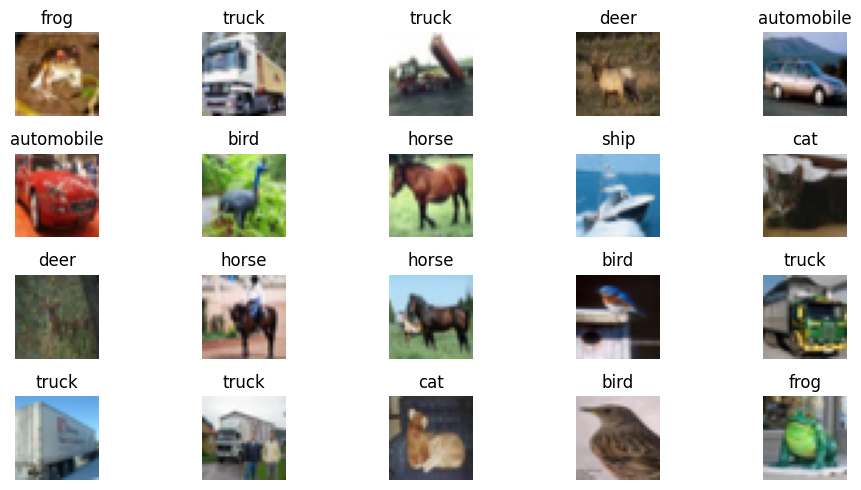

In [5]:
# Display sample CIFAR-10 images
plt.figure(figsize=(10, 5))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train_full[i])
    plt.title(class_names[int(y_train_full[i][0])])
    plt.axis("off")

plt.tight_layout()
plt.show()

**Step 2 - Data Preparation**

In [6]:
from sklearn.model_selection import train_test_split

# Normalise pixel values from 0-255 to 0-1
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Split labels from shape (50000, 1) to (50000,)
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# Create training and validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=10000,
    random_state=42,
    stratify=y_train_full
)

print("Training data:", X_train.shape)
print("Training labels:", y_train.shape)
print("Validation data:", X_val.shape)
print("Validation labels:", y_val.shape)
print("Test data:", X_test.shape)
print("Test labels:", y_test.shape)

Training data: (40000, 32, 32, 3)
Training labels: (40000,)
Validation data: (10000, 32, 32, 3)
Validation labels: (10000,)
Test data: (10000, 32, 32, 3)
Test labels: (10000,)


**STEP 2.1 - CREATE DATASET SPLIT TABLE**

In [7]:
import pandas as pd

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Number of Images": [len(X_train), len(X_val), len(X_test)],
    "Purpose": [
        "Used to learn model weights",
        "Used to tune model design and detect overfitting",
        "Used only for final unbiased evaluation"
    ]
})

split_summary

,Dataset,Number of Images,Purpose
0,Training,40000,Used to learn model weights
1,Validation,10000,Used to tune model design and detect overfitting
2,Test,10000,Used only for final unbiased evaluation


**Step 2.2 - Check Class Balance**

In [8]:
import numpy as np
import pandas as pd

train_class_counts = pd.Series(y_train).value_counts().sort_index()
val_class_counts = pd.Series(y_val).value_counts().sort_index()
test_class_counts = pd.Series(y_test).value_counts().sort_index()

class_balance = pd.DataFrame({
    "Class": class_names,
    "Training": train_class_counts.values,
    "Validation": val_class_counts.values,
    "Test": test_class_counts.values
})

class_balance

,Class,Training,Validation,Test
0,airplane,4000,1000,1000
1,automobile,4000,1000,1000
2,bird,4000,1000,1000
3,cat,4000,1000,1000
4,deer,4000,1000,1000
5,dog,4000,1000,1000
6,frog,4000,1000,1000
7,horse,4000,1000,1000
8,ship,4000,1000,1000
9,truck,4000,1000,1000


**Step 3.1 - Buiild Baseline CNN**

In [12]:
from tensorflow.keras import models, layers

baseline_cnn = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

baseline_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

**3.2 - Compile the Baseline CNN**

In [14]:
baseline_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**Step 3.3 - Train the Baseline CNN**

In [15]:
EPOCHS = 20
BATCH_SIZE = 64

baseline_history = baseline_cnn.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3928 - loss: 1.6482 - val_accuracy: 0.5496 - val_loss: 1.2713
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5537 - loss: 1.2479 - val_accuracy: 0.6201 - val_loss: 1.0708
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6262 - loss: 1.0671 - val_accuracy: 0.6613 - val_loss: 0.9824
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6674 - loss: 0.9538 - val_accuracy: 0.6839 - val_loss: 0.8984
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6978 - loss: 0.8671 - val_accuracy: 0.6731 - val_loss: 0.9347
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7215 - loss: 0.7999 - val_accuracy: 0.7094 - val_loss: 0.8355
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7459 - loss: 0.7318 - val_accuracy: 0.7208 - val_loss: 0.8017
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7610 - loss: 0.6794 - val_accuracy: 0

**Step 3.4 - Plot Baseline Accuracy Curve**

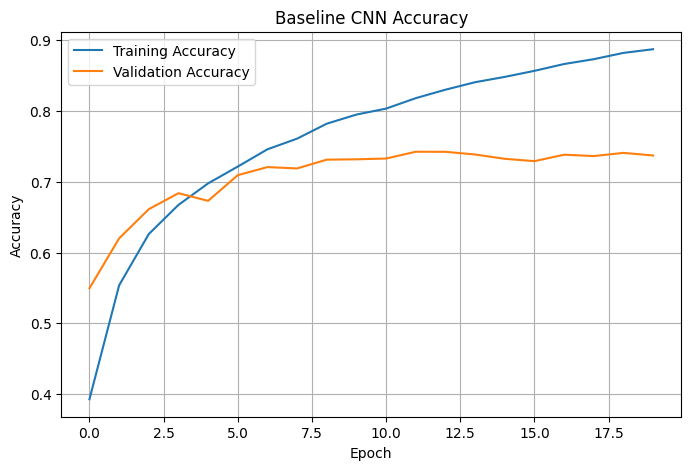

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(baseline_history.history["accuracy"], label="Training Accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**Step 3.5 - Plot Baseloine Loss Curve**

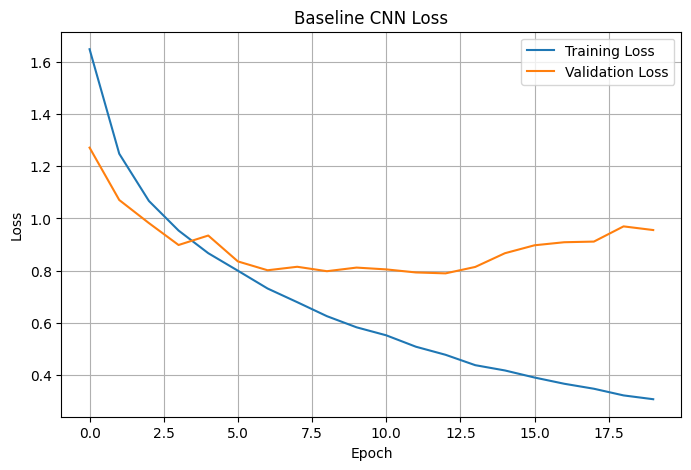

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(baseline_history.history["loss"], label="Training Loss")
plt.plot(baseline_history.history["val_loss"], label="Validation Loss")
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

**Step 3.6 Evaluate Baseline CNN on Test Set**

In [18]:
baseline_test_loss, baseline_test_accuracy = baseline_cnn.evaluate(X_test, y_test, verbose=0)

print("Baseline CNN Test Loss:", baseline_test_loss)
print("Baseline CNN Test Accuracy:", baseline_test_accuracy)

Baseline CNN Test Loss: 0.9621181488037109
Baseline CNN Test Accuracy: 0.7426000237464905


**Step 3.7 - Save Baseline Results for Later Comparison**

In [19]:
baseline_results = {
    "Model": "Baseline CNN",
    "Training Accuracy": 0.8874,
    "Validation Accuracy": 0.7372,
    "Test Accuracy": baseline_test_accuracy,
    "Training Loss": 0.3078,
    "Validation Loss": 0.9557,
    "Test Loss": baseline_test_loss,
    "Epochs": 20,
    "Batch Size": 64,
    "Learning Rate": 0.001
}

baseline_results

{'Model': 'Baseline CNN',
 'Training Accuracy': 0.8874,
 'Validation Accuracy': 0.7372,
 'Test Accuracy': 0.7426000237464905,
 'Training Loss': 0.3078,
 'Validation Loss': 0.9557,
 'Test Loss': 0.9621181488037109,
 'Epochs': 20,
 'Batch Size': 64,
 'Learning Rate': 0.001}

In [20]:
results_table = pd.DataFrame([baseline_results])
results_table

,Model,Training Accuracy,Validation Accuracy,Test Accuracy,Training Loss,Validation Loss,Test Loss,Epochs,Batch Size,Learning Rate
0,Baseline CNN,0.8874,0.7372,0.7426,0.3078,0.9557,0.962118,20,64,0.001


**Step 4.1 - Create Data Augmentation Pipeline**

In [21]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

**Step 4.2 - Build Improved CNN**

In [22]:
improved_cnn = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.40),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.50),
    layers.Dense(10, activation="softmax")
])

improved_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,02

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

**Step 4.3 — Compile Improved CNN**

In [23]:
improved_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**Step 4.4 — Add Callbacks**

In [24]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

**Step 4.5 — Train Improved CNN**

In [25]:
IMPROVED_EPOCHS = 40
IMPROVED_BATCH_SIZE = 64

improved_history = improved_cnn.fit(
    X_train,
    y_train,
    epochs=IMPROVED_EPOCHS,
    batch_size=IMPROVED_BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.3638 - loss: 1.8988 - val_accuracy: 0.3544 - val_loss: 1.9443 - learning_rate: 0.0010
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.4972 - loss: 1.4050 - val_accuracy: 0.5128 - val_loss: 1.4733 - learning_rate: 0.0010
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.5606 - loss: 1.2298 - val_accuracy: 0.4336 - val_loss: 1.8151 - learning_rate: 0.0010
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6003 - loss: 1.1329 - val_accuracy: 0.5650 - val_loss: 1.2929 - learning_rate: 0.0010
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6281 - loss: 1.0556 - val_accuracy: 0.6667 - val_loss: 0.9620 - learning_rate: 0.0010
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.6478 - loss: 0.9981 - val_accuracy: 0.6875 - val_loss: 0.8926 - learning_rate: 0.0010
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.6680 - l

**Step 4.6 — Plot Improved Accuracy Curve**

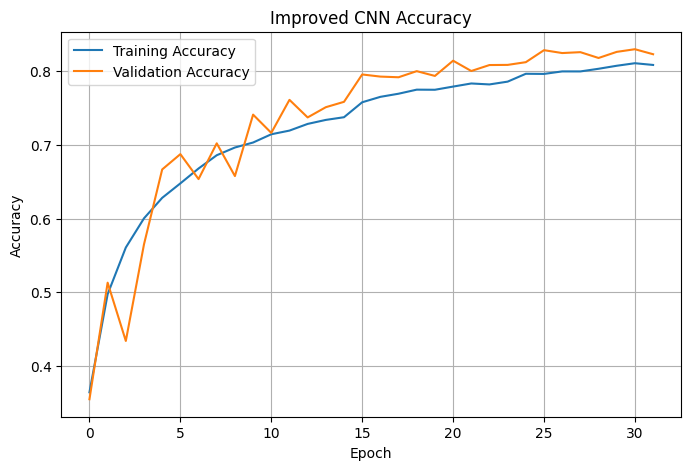

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(improved_history.history["accuracy"], label="Training Accuracy")
plt.plot(improved_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Improved CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**Step 4.7 — Plot Improved Loss Curve**

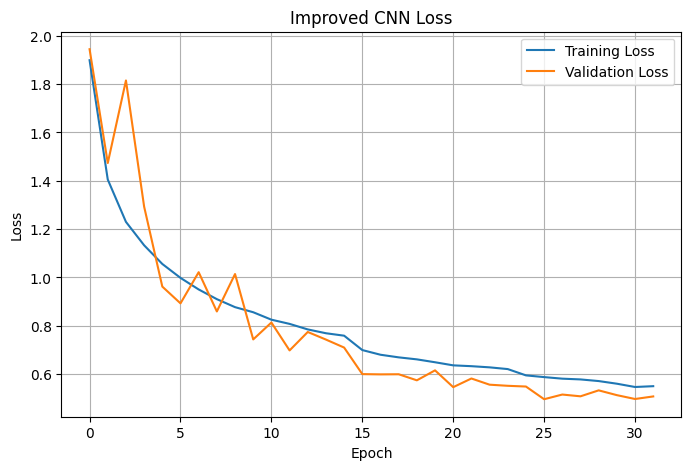

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(improved_history.history["loss"], label="Training Loss")
plt.plot(improved_history.history["val_loss"], label="Validation Loss")
plt.title("Improved CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

**Step 4.8 — Evaluate Improved CNN on Test Set**

In [28]:
improved_test_loss, improved_test_accuracy = improved_cnn.evaluate(X_test, y_test, verbose=0)

print("Improved CNN Test Loss:", improved_test_loss)
print("Improved CNN Test Accuracy:", improved_test_accuracy)

Improved CNN Test Loss: 0.515151858329773
Improved CNN Test Accuracy: 0.8251000046730042


**Step 4.10 — Save Improved CNN Results**

In [29]:
improved_results = {
    "Model": "Improved CNN",
    "Training Accuracy": 0.8087,
    "Validation Accuracy": 0.8233,
    "Best Validation Accuracy": 0.8301,
    "Test Accuracy": improved_test_accuracy,
    "Training Loss": 0.5499,
    "Validation Loss": 0.5075,
    "Test Loss": improved_test_loss,
    "Epochs": len(improved_history.history["accuracy"]),
    "Batch Size": 64,
    "Learning Rate": "0.001 with ReduceLROnPlateau"
}

improved_results

{'Model': 'Improved CNN',
 'Training Accuracy': 0.8087,
 'Validation Accuracy': 0.8233,
 'Best Validation Accuracy': 0.8301,
 'Test Accuracy': 0.8251000046730042,
 'Training Loss': 0.5499,
 'Validation Loss': 0.5075,
 'Test Loss': 0.515151858329773,
 'Epochs': 32,
 'Batch Size': 64,
 'Learning Rate': '0.001 with ReduceLROnPlateau'}

In [30]:
results_table = pd.DataFrame([baseline_results, improved_results])
results_table

,Model,Training Accuracy,Validation Accuracy,Test Accuracy,Training Loss,Validation Loss,Test Loss,Epochs,Batch Size,Learning Rate,Best Validation Accuracy
0,Baseline CNN,0.8874,0.7372,0.7426,0.3078,0.9557,0.962118,20,64,0.001,NaN
1,Improved CNN,0.8087,0.8233,0.8251,0.5499,0.5075,0.515152,32,64,0.001 with ReduceLROnPlateau,0.8301


In [32]:
results_table.to_csv("cnn_results_comparison.csv", index=False)

**Step 5.1 — Generate Predictions Using Improved CNN**

In [33]:
# Generate predictions using the improved CNN
y_pred_probs = improved_cnn.predict(X_test)

# Convert predicted probabilities into class labels
y_pred = np.argmax(y_pred_probs, axis=1)

print("Prediction probabilities shape:", y_pred_probs.shape)
print("Predicted labels shape:", y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Prediction probabilities shape: (10000, 10)
Predicted labels shape: (10000,)


**Step 5.2: Classification Report**

In [35]:
from sklearn.metrics import classification_report
import pandas as pd

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True
)

classification_report_df = pd.DataFrame(report_dict).transpose()

classification_report_df

,precision,recall,f1-score,support
airplane,0.841414,0.8330,0.837186,1000.0000
automobile,0.913001,0.9340,0.923381,1000.0000
bird,0.830823,0.7170,0.769726,1000.0000
cat,0.787645,0.6120,0.688801,1000.0000
deer,0.767161,0.8270,0.795958,1000.0000
dog,0.802928,0.7130,0.755297,1000.0000
frog,0.736675,0.9260,0.820558,1000.0000
horse,0.858268,0.8720,0.865079,1000.0000
ship,0.884016,0.9070,0.895360,1000.0000
truck,0.841035,0.9100,0.874159,1000.0000


**Step 5.3: Generate Confusion Matrix**

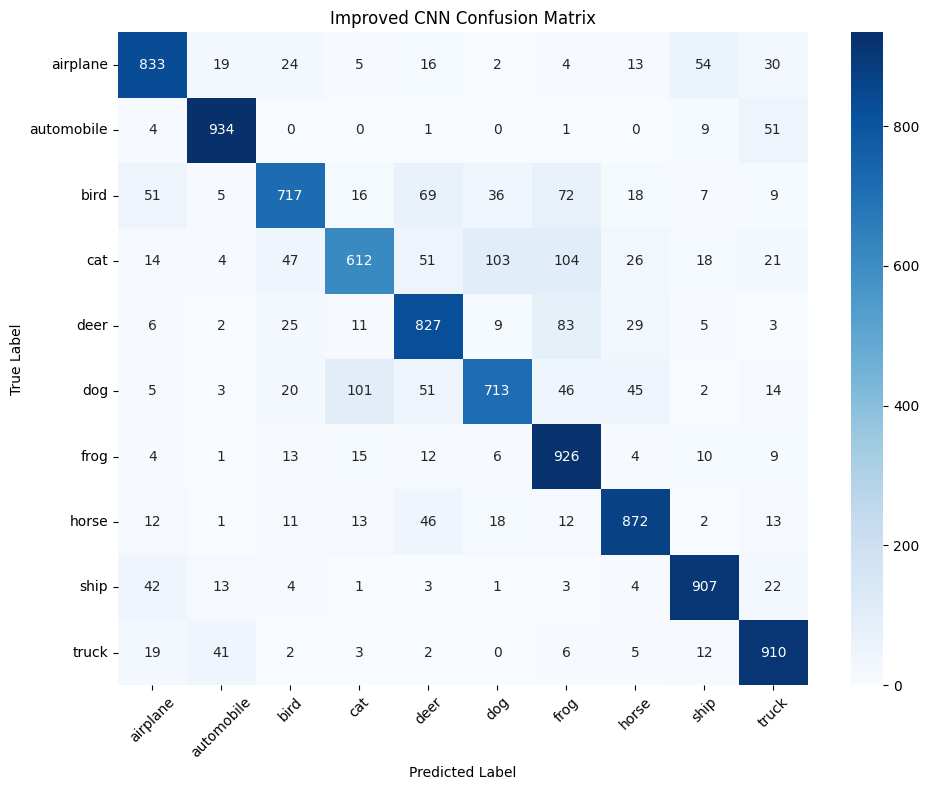

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Improved CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
# Find one correctly predicted test image for demo
all_prediction_probs = improved_cnn.predict(X_test)
all_predictions = np.argmax(all_prediction_probs, axis=1)

correct_indices = np.where(all_predictions == y_test)[0]

demo_index = correct_indices[0]

print("Selected demo index:", demo_index)
print("Actual label:", class_names[y_test[demo_index]])
print("Predicted label:", class_names[all_predictions[demo_index]])
print("Confidence:", round(np.max(all_prediction_probs[demo_index]) * 100, 2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Selected demo index: 0
Actual label: cat
Predicted label: cat
Confidence: 78.89 %


**Demo Prediction Slide Output**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Actual label: dog
Predicted label: dog
Prediction confidence: 61.83 %

Top 5 predicted classes:
dog: 61.83%
cat: 24.60%
frog: 10.01%
deer: 1.56%
horse: 0.75%


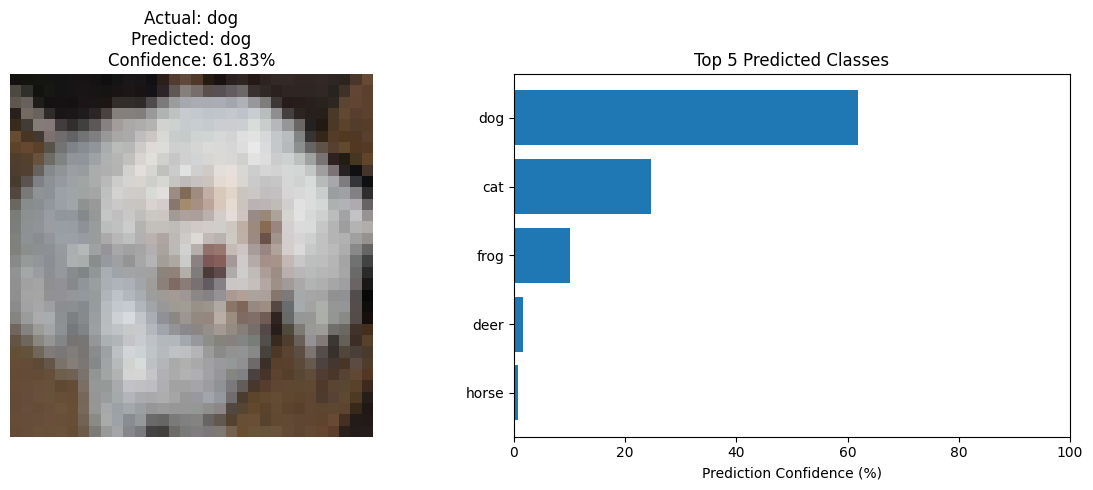

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Demo: Improved CNN prediction on one CIFAR-10 test image
# -------------------------------------------------------

# Choose a test image index.
# You can change this number to show a different example.
demo_index = 1000

# Get image and true label
demo_image = X_test[demo_index]
true_label_index = y_test[demo_index]
true_label = class_names[true_label_index]

# Model expects a batch dimension: (1, 32, 32, 3)
demo_image_batch = np.expand_dims(demo_image, axis=0)

# Generate prediction probabilities
demo_prediction_probs = improved_cnn.predict(demo_image_batch)

# Get predicted class and confidence
predicted_label_index = np.argmax(demo_prediction_probs[0])
predicted_label = class_names[predicted_label_index]
confidence = demo_prediction_probs[0][predicted_label_index]

# Display result
print("Actual label:", true_label)
print("Predicted label:", predicted_label)
print("Prediction confidence:", round(confidence * 100, 2), "%")

# Show top 5 probabilities
top_5_indices = np.argsort(demo_prediction_probs[0])[-5:][::-1]

print("\nTop 5 predicted classes:")
for i in top_5_indices:
    print(f"{class_names[i]}: {demo_prediction_probs[0][i] * 100:.2f}%")

# -------------------------------------------------------
# Visual output for slide/demo
# -------------------------------------------------------

plt.figure(figsize=(12, 5))

# Image display
plt.subplot(1, 2, 1)
plt.imshow(demo_image)
plt.axis("off")
plt.title(
    f"Actual: {true_label}\nPredicted: {predicted_label}\nConfidence: {confidence * 100:.2f}%",
    fontsize=12
)

# Top 5 probability bar chart
plt.subplot(1, 2, 2)
top_5_labels = [class_names[i] for i in top_5_indices]
top_5_values = [demo_prediction_probs[0][i] * 100 for i in top_5_indices]

plt.barh(top_5_labels[::-1], top_5_values[::-1])
plt.xlabel("Prediction Confidence (%)")
plt.title("Top 5 Predicted Classes")
plt.xlim(0, 100)

plt.tight_layout()
plt.show()